#### IndMask results analysis

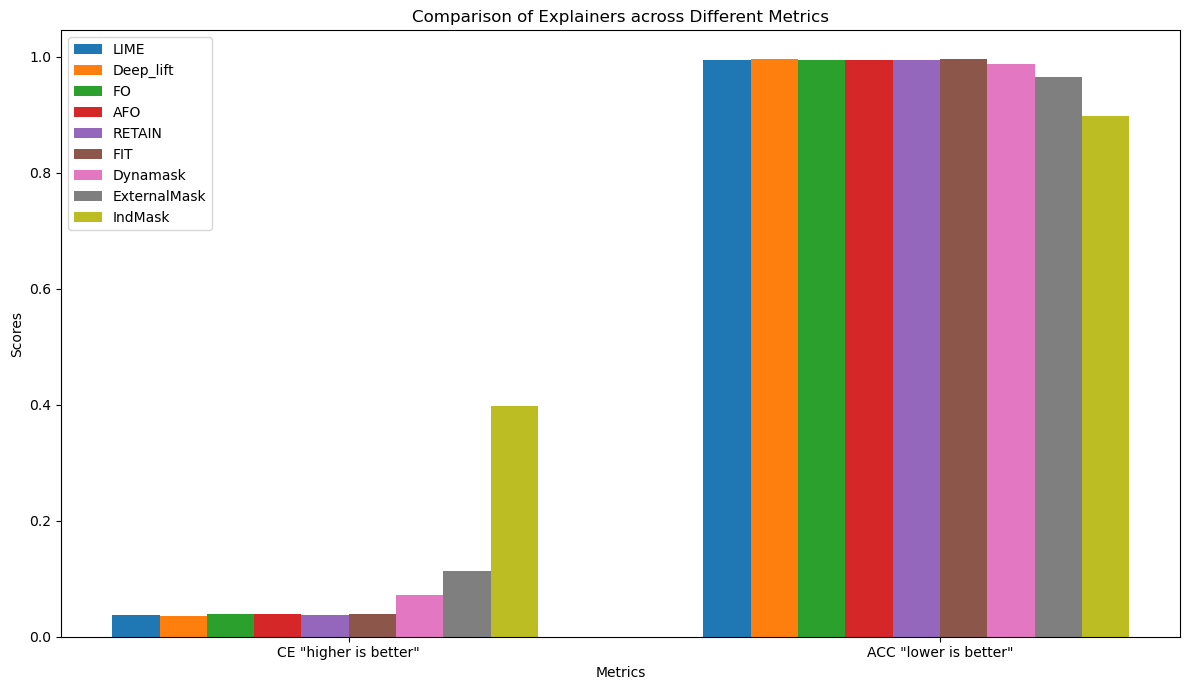

In [1]:
## Classification task 

import matplotlib.pyplot as plt
import numpy as np

# Metrics 
metrics = ['CE "higher is better"', 'ACC "lower is better"']

''' Explainer methods as presented in the paper Table 2: Results of each explanation method, after perturbing the masked data, compared with our proposed method IndMask after perturbing
the corresponding amount of masked data. The trained black-box model is a GRU-based architecture on MIMIC data. Results show that
IndMask outperforms all the baselines. Per metric, ↓ indicates that a lower value is better, and ↑ higher is better. '''

explainers = ['LIME', 'Deep_lift', 'FO', 'AFO', 'RETAIN', 'FIT', 'Dynamask', 'ExternalMask', 'IndMask']

data = {
    'LIME': [0.0382, 0.9952],
    'Deep_lift': [0.0362, 0.9954],
    'FO': [0.0386, 0.9948],
    'AFO': [0.0391, 0.9952],
    'RETAIN': [0.0379, 0.9950],
    'FIT': [0.0387, 0.9959],
    'Dynamask': [0.0713, 0.9870],
    'ExternalMask': [0.1134, 0.9656],
    'IndMask': [0.3986, 0.8977, 0.5560, 0.6759],
}

# Convert data to numpy arrays for plotting
bar_width = 0.08
index = np.arange(len(metrics))

# Initialize plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each explainer's metrics
for i, explainer in enumerate(explainers):
    plt.bar(index + i * bar_width, data[explainer], bar_width, label=explainer)

# Labels and ticks
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Comparison of Explainers across Different Metrics')
plt.xticks(index + bar_width * (len(explainers) / 2), metrics)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

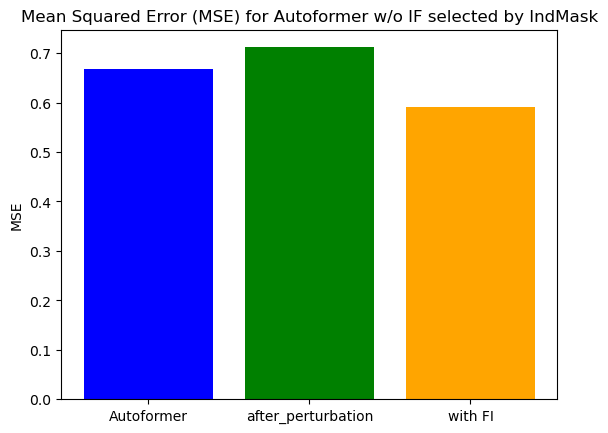

In [19]:
# Forecasting
model = ["Autoformer","after_perturbation", "with FI"]
MSE = {
    "autoformer": 0.668,
    "after_pert": 0.712,
    "with FI": 0.59,
}

mse_values = [0.668, 0.712, 0.59]

plt.bar(model, mse_values ,color=['blue','green','orange'])

plt.title('Mean Squared Error (MSE) for Autoformer w/o IF selected by IndMask')
#plt.xlabel('Model')
plt.ylabel('MSE')

plt.show()


### Hyperparameter tunning

Gama Hyperparameter tuning. γ is the weight of elementwise
entropy, which we use to tune the number of important features
selected by IndMask. Performance metrics are reported for different
values of γ with experiments performed on the HAR data. Increasing
the value of γ leads to better performance but with denser masks.γ
allows us to control the sparsity of the explanation, a desirable property
highlighted in the literature.

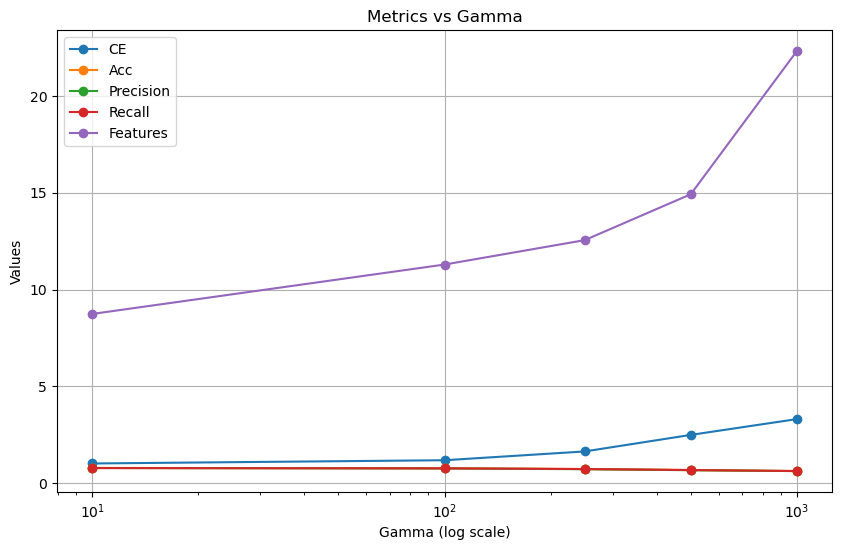

In [21]:
# Data from table 4 in the paper
gamma_values = [10, 100, 250, 500, 1000]
CE = [1.0189, 1.186, 1.64, 2.494, 3.31]
Acc = [0.789, 0.769, 0.731, 0.679, 0.624]
Precision = [0.785, 0.763, 0.723, 0.671, 0.627]
Recall = [0.781, 0.768, 0.732, 0.680, 0.629]
Features = [8.74, 11.29, 12.55, 14.92, 22.31]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(gamma_values, CE, marker='o', label='CE')
plt.plot(gamma_values, Acc, marker='o', label='Acc')
plt.plot(gamma_values, Precision, marker='o', label='Precision')
plt.plot(gamma_values, Recall, marker='o', label='Recall')
plt.plot(gamma_values, Features, marker='o', label='Features')

plt.xscale('log')
plt.xlabel('Gamma (log scale)')
plt.ylabel('Values')
plt.title('Metrics vs Gamma')
plt.legend()
plt.grid(True)
plt.show()
